# OULAD ANALYSIS — Censored Modelling, Cross-Validation and Non-Parametric Inference

## 1. Setup and project location

In [1]:
import os, gc, json, warnings, time
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import randint
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     RandomizedSearchCV, train_test_split)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100

# Project location
BASE_DIR = Path(r"C:\Users\anekp\OneDrive\Desktop\FOLDERS\PUPLICATION\EMTAN CONF PAPAER\desktop-publication-OPEN UNIVERSITY LEARNING ANALYTIC DATASET")
if not BASE_DIR.exists():
    raise FileNotFoundError(f'Not found: {BASE_DIR}')

RAW_DIR = BASE_DIR / 'data' / 'raw'
PROC_DIR = BASE_DIR / 'data' / 'processed'
RES_DIR = BASE_DIR / 'results'
FIG_DIR = BASE_DIR / 'figures'
for d in (RES_DIR, FIG_DIR, PROC_DIR):
    d.mkdir(parents=True, exist_ok=True)

RAW_DIR, RES_DIR, FIG_DIR, PROC_DIR = str(RAW_DIR), str(RES_DIR), str(FIG_DIR), str(PROC_DIR)
KEY = ['code_module', 'code_presentation', 'id_student']

print('BASE_DIR:', BASE_DIR)
for n in ['studentInfo', 'studentRegistration', 'studentAssessment',
          'studentVle', 'assessments', 'vle', 'courses']:
    p = Path(RAW_DIR) / f'{n}.csv'
    print(f'  {n+".csv":<26}{p.stat().st_size/1e6:>9,.1f} MB' if p.exists()
          else f'  {n+".csv":<26}   MISSING')

BASE_DIR: C:\Users\anekp\OneDrive\Desktop\FOLDERS\PUPLICATION\EMTAN CONF PAPAER\desktop-publication-OPEN UNIVERSITY LEARNING ANALYTIC DATASET
  studentInfo.csv                 3.5 MB
  studentRegistration.csv         1.1 MB
  studentAssessment.csv           5.7 MB
  studentVle.csv                453.8 MB
  assessments.csv                 0.0 MB
  vle.csv                         0.3 MB
  courses.csv                     0.0 MB


## 2. Load the raw tables

In [2]:
# studentVle.csv is 10.66M rows / ~454 MB. Compact dtypes keep it near 150 MB in memory.
studentInfo         = pd.read_csv(Path(RAW_DIR) / 'studentInfo.csv')
studentRegistration = pd.read_csv(Path(RAW_DIR) / 'studentRegistration.csv')
studentAssessment   = pd.read_csv(Path(RAW_DIR) / 'studentAssessment.csv')
assessments         = pd.read_csv(Path(RAW_DIR) / 'assessments.csv')
studentVle          = pd.read_csv(Path(RAW_DIR) / 'studentVle.csv', dtype={
    'code_module': 'category', 'code_presentation': 'category',
    'id_student': 'int32', 'id_site': 'int32', 'date': 'int16', 'sum_click': 'int16'})

print('studentVle :', studentVle.shape,
      '| %.0f MB' % (studentVle.memory_usage(deep=True).sum() / 1e6))
print('studentInfo:', studentInfo.shape,
      '| unique students:', studentInfo.id_student.nunique())

studentVle : (10655280, 6) | 149 MB
studentInfo: (32593, 12) | unique students: 28785


## 3. Full demographic breakdown

In [3]:
def demographic_table(df, col, order=None):
    vc = df[col].fillna('Missing').value_counts()
    if order:
        vc = vc.reindex([o for o in order if o in vc.index]).dropna()
    out = pd.DataFrame({'n': vc.astype(int)})
    out['%'] = (out['n'] / len(df) * 100).round(2)
    out.index.name = 'category'
    return out

DEMOG = {
    'gender': None,
    'age_band': ['0-35', '35-55', '55<='],
    'disability': ['N', 'Y'],
    'highest_education': ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
                          'HE Qualification', 'Post Graduate Qualification'],
    'region': None,
    'imd_band': None,
}
tabs = {c: demographic_table(studentInfo, c, o) for c, o in DEMOG.items()}
for c, t in tabs.items():
    print(f'\n--- {c}  (n={t["n"].sum():,}, {t["%"].sum():.2f}%) ---')
    print(t.to_string())
pd.concat(tabs, names=['characteristic']).to_csv(Path(RES_DIR) / 'table2_demographics_full.csv')

print('\n--- final_result ---')
print(demographic_table(studentInfo, 'final_result').to_string())


--- gender  (n=32,593, 100.00%) ---
              n      %
category              
M         17875  54.84
F         14718  45.16

--- age_band  (n=32,593, 100.00%) ---
              n      %
category              
0-35      22944  70.40
35-55      9433  28.94
55<=        216   0.66

--- disability  (n=32,593, 100.00%) ---
              n      %
category              
N         29429  90.29
Y          3164   9.71

--- highest_education  (n=32,593, 99.99%) ---
                                 n      %
category                                 
No Formal quals                347   1.06
Lower Than A Level           13158  40.37
A Level or Equivalent        14045  43.09
HE Qualification              4730  14.51
Post Graduate Qualification    313   0.96

--- region  (n=32,593, 100.00%) ---
                         n      %
category                         
Scotland              3446  10.57
East Anglian Region   3340  10.25
London Region         3216   9.87
South Region          3092   9.49
No

## 4. Censored feature construction

The students already unregistered by *T* are excluded because their outcome is known at prediction time, and both engagement windows close at *T*, so the ratio cannot be driven by post-withdrawal absence. 

In [4]:
def build_features(T, half=None):
    """Return only what a system deployed on day T could actually observe.

    Registrations whose date_unregistration falls on or before T are dropped: for those
    students the outcome is already known at the prediction moment, so retaining them
    manufactures accuracy. Early and late windows both close at T, so the engagement
    ratio cannot be driven by the absence of activity that follows withdrawal.
    """
    if half is None:
        half = T // 2

    reg = studentRegistration.copy()
    still_on = reg['date_unregistration'].isna() | (reg['date_unregistration'] > T)
    reg = reg.loc[still_on, KEY + ['date_registration', 'date_unregistration']]

    v = studentVle.loc[studentVle['date'] <= T]
    eng = v.groupby(KEY, observed=True).agg(
        total_clicks=('sum_click', 'sum'),
        n_active_days=('date', 'nunique'),
        n_unique_resources=('id_site', 'nunique')).reset_index()
    early = (v.loc[v['date'] <= half].groupby(KEY, observed=True)['sum_click']
             .sum().rename('clicks_early').reset_index())
    late = (v.loc[v['date'] > half].groupby(KEY, observed=True)['sum_click']
            .sum().rename('clicks_late').reset_index())
    eng = eng.merge(early, on=KEY, how='left').merge(late, on=KEY, how='left')
    # studentVle was read with categorical keys; merging a categorical against an object
    # key does not match reliably, so cast back to str before any merge.
    for c in ['code_module', 'code_presentation']:
        eng[c] = eng[c].astype(str)
    del v; gc.collect()

    a = studentAssessment.merge(
        assessments[['id_assessment', 'code_module', 'code_presentation', 'date', 'weight']],
        on='id_assessment', how='left', suffixes=('', '_due'))
    a = a.loc[a['date_submitted'] <= T]
    a['is_late'] = (a['date_submitted'] > a['date']).astype(float)
    a['weighted_component'] = a['score'] * a['weight'] / 100.0
    asg = a.groupby(KEY).agg(
        n_assessments_submitted=('id_assessment', 'count'),
        avg_assessment_score=('score', 'mean'),
        n_late_submissions=('is_late', 'sum'),
        weighted_score_sum=('weighted_component', 'sum')).reset_index()

    df = (studentInfo.merge(reg, on=KEY, how='inner')
          .merge(eng, on=KEY, how='left')
          .merge(asg, on=KEY, how='left'))
    for c in ['total_clicks', 'n_active_days', 'n_unique_resources', 'clicks_early',
              'clicks_late', 'n_assessments_submitted', 'n_late_submissions',
              'weighted_score_sum']:
        df[c] = df[c].fillna(0)
    df['avg_assessment_score'] = df['avg_assessment_score'].fillna(-1)  # explicit "no submission"
    df['has_submissions'] = (df['n_assessments_submitted'] > 0).astype(int)
    df['avg_clicks_per_active_day'] = (
        df['total_clicks'] / df['n_active_days'].replace(0, np.nan)).fillna(0)
    df['early_late_ratio'] = (df['clicks_early'] + 1) / (df['clicks_late'] + 1)
    df['imd_band'] = df['imd_band'].fillna('Unknown')
    df['date_registration'] = df['date_registration'].fillna(df['date_registration'].median())
    df['at_risk'] = df['final_result'].isin(['Fail', 'Withdrawn']).astype(int)
    return df

frames = {}
for T in [14, 28, 42, 56, 84]:
    frames[T] = build_features(T)
    print(f'T={T:3d}: {len(frames[T]):,} eligible of {len(studentInfo):,} '
          f'({len(studentInfo)-len(frames[T]):,} already unregistered)')
d28 = frames[28]

T= 14: 28,119 eligible of 32,593 (4,474 already unregistered)
T= 28: 27,538 eligible of 32,593 (5,055 already unregistered)
T= 42: 27,024 eligible of 32,593 (5,569 already unregistered)
T= 56: 26,522 eligible of 32,593 (6,071 already unregistered)
T= 84: 25,724 eligible of 32,593 (6,869 already unregistered)


## 5. Early:late ratio, naive versus censored

In [5]:
# Naive specification: windows split at day 28 with no upper bound, whole cohort.
eng_all = pd.concat([
    studentVle.loc[studentVle['date'] <= 28].groupby(KEY, observed=True)['sum_click']
        .sum().rename('clicks_early'),
    studentVle.loc[studentVle['date'] > 28].groupby(KEY, observed=True)['sum_click']
        .sum().rename('clicks_late'),
], axis=1).fillna(0).reset_index()
for c in ['code_module', 'code_presentation']:
    eng_all[c] = eng_all[c].astype(str)

naive = studentInfo.merge(eng_all, on=KEY, how='left')
naive[['clicks_early', 'clicks_late']] = naive[['clicks_early', 'clicks_late']].fillna(0)
naive['early_late_ratio'] = (naive['clicks_early'] + 1) / (naive['clicks_late'] + 1)

def ratio_table(df, label):
    g = df.groupby('final_result').agg(
        n=('early_late_ratio', 'size'),
        mean_ratio=('early_late_ratio', 'mean'),
        median_ratio=('early_late_ratio', 'median'),
        q1=('early_late_ratio', lambda s: s.quantile(.25)),
        q3=('early_late_ratio', lambda s: s.quantile(.75))).round(3)
    g.insert(0, 'specification', label)
    return g.reindex(['Distinction', 'Pass', 'Fail', 'Withdrawn'])

ratio_cmp = pd.concat([ratio_table(naive, 'naive (uncensored)'),
                       ratio_table(frames[56], 'censored day 56, survivors')])
print(ratio_cmp.to_string())
ratio_cmp.to_csv(Path(RES_DIR) / 'table4b_early_late_ratio_censored.csv')

                           specification      n  mean_ratio  median_ratio     q1     q3
final_result                                                                           
Distinction           naive (uncensored)   3024       0.296         0.257  0.167  0.378
Pass                  naive (uncensored)  12361       0.321         0.262  0.161  0.403
Fail                  naive (uncensored)   7052      10.448         0.835  0.342  2.401
Withdrawn             naive (uncensored)  10156      30.479         1.051  1.000  9.238
Distinction   censored day 56, survivors   3024       3.269         1.882  1.271  2.872
Pass          censored day 56, survivors  12361       3.383         1.798  1.134  2.907
Fail          censored day 56, survivors   7044      14.511         2.351  1.120  6.316
Withdrawn     censored day 56, survivors   4093      15.021         2.440  1.289  5.465


## 6. Dispersion and non-parametric inference

At *n* ≈ 27,500 almost any difference reaches significance, so epsilon-squared and
rank-biserial effect sizes carry the interpretation, not the *p* values.

In [6]:
def holm(p):
    """Holm step-down adjusted p-values."""
    o = np.argsort(p); m = len(p); adj = np.empty(m); run = 0.0
    for r, i in enumerate(o):
        run = max(run, (m - r) * p[i]); adj[i] = min(run, 1.0)
    return adj

def describe_and_test(df, metrics, group='final_result'):
    order = [o for o in ['Distinction', 'Pass', 'Fail', 'Withdrawn'] if o in df[group].unique()]
    dsc, omn, pr = [], [], []
    for m in metrics:
        gs = [df.loc[df[group] == g, m].dropna().values for g in order]
        for g, v in zip(order, gs):
            dsc.append({'metric': m, group: g, 'n': len(v), 'mean': np.mean(v),
                        'sd': np.std(v, ddof=1), 'median': np.median(v),
                        'q1': np.percentile(v, 25), 'q3': np.percentile(v, 75)})
        H, p = stats.kruskal(*gs)
        n, k = sum(len(g) for g in gs), len(gs)
        omn.append({'metric': m, 'H': H, 'df': k - 1, 'p': p,
                    'epsilon_squared': (H - k + 1) / (n - k), 'n': n})
        raw = []
        for i in range(len(order)):
            for j in range(i + 1, len(order)):
                U, pp = stats.mannwhitneyu(gs[i], gs[j], alternative='two-sided')
                raw.append({'metric': m, 'group_1': order[i], 'group_2': order[j], 'U': U,
                            'p_raw': pp,
                            'rank_biserial': 2 * U / (len(gs[i]) * len(gs[j])) - 1})
        for r, pa in zip(raw, holm(np.array([r['p_raw'] for r in raw]))):
            r['p_holm'] = pa
        pr += raw
    return pd.DataFrame(dsc).round(3), pd.DataFrame(omn).round(6), pd.DataFrame(pr).round(6)

METRICS = ['total_clicks', 'n_active_days', 'early_late_ratio', 'avg_assessment_score']
desc, omni, pair = describe_and_test(d28, METRICS)
print('=== dispersion, day-28 censored ===')
print(desc.to_string(index=False))
print('\n=== Kruskal-Wallis ===')
print(omni.to_string(index=False))

desc.to_csv(Path(RES_DIR) / 'table4_dispersion.csv', index=False)
omni.to_csv(Path(RES_DIR) / 'table4_kruskal_wallis.csv', index=False)
pair.to_csv(Path(RES_DIR) / 'table4_pairwise_mannwhitney_holm.csv', index=False)

=== dispersion, day-28 censored ===
              metric final_result     n    mean      sd  median      q1      q3
        total_clicks  Distinction  3024 568.928 600.391 396.000 176.000 750.250
        total_clicks         Pass 12361 409.548 445.332 280.000 127.000 540.000
        total_clicks         Fail  7044 224.123 297.351 131.000  39.000 292.000
        total_clicks    Withdrawn  5109 286.248 350.735 183.000  73.000 376.000
       n_active_days  Distinction  3024  19.872  11.255  19.000  11.000  28.000
       n_active_days         Pass 12361  16.535  10.297  15.000   8.000  23.000
       n_active_days         Fail  7044  10.370   8.719   8.000   4.000  15.000
       n_active_days    Withdrawn  5109  12.890   9.436  11.000   6.000  18.000
    early_late_ratio  Distinction  3024   5.349  21.865   1.886   1.031   3.544
    early_late_ratio         Pass 12361   4.799  18.290   1.634   0.849   3.192
    early_late_ratio         Fail  7044   7.579  26.601   1.407   0.718   3.814
    

## 7. Specification D — the conventional uncensored treatment

In [7]:
# Specification D: the conventional OULAD treatment. Whole-module features, no cut-off,
# no exclusion of already-unregistered students. Used later to measure the leakage.
v_agg = studentVle.groupby(KEY, observed=True).agg(
    total_clicks=('sum_click', 'sum'),
    n_active_days=('date', 'nunique'),
    n_unique_resources=('id_site', 'nunique')).reset_index()
for c in ['code_module', 'code_presentation']:
    v_agg[c] = v_agg[c].astype(str)

a2 = studentAssessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation', 'date', 'weight']],
    on='id_assessment', how='left', suffixes=('', '_due'))
a2['is_late'] = (a2['date_submitted'] > a2['date']).astype(float)
a2['weighted_component'] = a2['score'] * a2['weight'] / 100.0
a_agg = a2.groupby(KEY).agg(
    n_assessments_submitted=('id_assessment', 'count'),
    avg_assessment_score=('score', 'mean'),
    n_late_submissions=('is_late', 'sum'),
    weighted_score_sum=('weighted_component', 'sum')).reset_index()

orig = (studentInfo.merge(v_agg, on=KEY, how='left')
        .merge(a_agg, on=KEY, how='left')
        .merge(eng_all, on=KEY, how='left'))
for c in ['total_clicks', 'n_active_days', 'n_unique_resources', 'clicks_early',
          'clicks_late', 'n_assessments_submitted', 'n_late_submissions', 'weighted_score_sum']:
    orig[c] = orig[c].fillna(0)
orig['avg_assessment_score'] = orig['avg_assessment_score'].fillna(-1)
orig['has_submissions'] = (orig['n_assessments_submitted'] > 0).astype(int)
orig['avg_clicks_per_active_day'] = (
    orig['total_clicks'] / orig['n_active_days'].replace(0, np.nan)).fillna(0)
orig['early_late_ratio'] = (orig['clicks_early'] + 1) / (orig['clicks_late'] + 1)
orig['imd_band'] = orig['imd_band'].fillna('Unknown')
orig['date_registration'] = 0.0   # constant: keeps the feature list identical to set C
orig['at_risk'] = orig['final_result'].isin(['Fail', 'Withdrawn']).astype(int)

desc_o, omni_o, _ = describe_and_test(orig, METRICS)
print('=== uncensored equivalent of the original Table 4 ===')
print(desc_o.to_string(index=False))
desc_o.to_csv(Path(RES_DIR) / 'table4_dispersion_uncensored.csv', index=False)

del studentVle; gc.collect()
print('\nstudentVle released from memory.')

=== uncensored equivalent of the original Table 4 ===
              metric final_result     n     mean       sd   median      q1       q3
        total_clicks  Distinction  3024 2666.759 2409.993 1896.000 942.000 3765.000
        total_clicks         Pass 12361 1921.809 1852.804 1343.000 683.000 2568.000
        total_clicks         Fail  7052  651.853  966.942  317.000  98.000  796.250
        total_clicks    Withdrawn 10156  313.950  608.630   89.000   0.000  373.000
       n_active_days  Distinction  3024  110.043   58.000  103.000  63.000  148.000
       n_active_days         Pass 12361   87.044   51.069   78.000  47.000  117.000
       n_active_days         Fail  7052   33.177   34.641   22.000   8.000   47.000
       n_active_days    Withdrawn 10156   16.289   23.418    7.000   0.000   23.000
    early_late_ratio  Distinction  3024    0.296    0.206    0.257   0.167    0.378
    early_late_ratio         Pass 12361    0.321    0.305    0.262   0.161    0.403
    early_late_ratio  

## 8. Modelling scaffolding

In [8]:
ENG  = ['total_clicks', 'n_active_days', 'n_unique_resources', 'clicks_early',
        'clicks_late', 'early_late_ratio', 'avg_clicks_per_active_day']
ASS  = ['n_assessments_submitted', 'avg_assessment_score', 'n_late_submissions',
        'weighted_score_sum', 'has_submissions']
DEMN = ['num_of_prev_attempts', 'studied_credits', 'date_registration']
DEMC = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']

SETS = {'A_engagement_only':           (ENG, []),
        'B_engagement_demographics':   (ENG + DEMN, DEMC),
        'C_plus_censored_assessment':  (ENG + DEMN + ASS, DEMC)}
TASKS = [('multiclass', 'final_result', False), ('binary_at_risk', 'at_risk', True)]

def make_xy(df, num, cat, target):
    X = df[num + cat].copy()
    if cat:
        X[cat] = OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1).fit_transform(X[cat].astype(str))
    return X.astype(float), df[target]

def evaluate(X, y, binary, n_trees=200):
    # Scaling sits inside the pipeline so it is fitted on training folds only.
    cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
    sc = {'accuracy': 'accuracy', 'macro_f1': 'f1_macro'}
    if binary:
        sc['roc_auc'] = 'roc_auc'
    models = {
        'LogisticRegression': Pipeline([
            ('sc', StandardScaler()),
            ('m', LogisticRegression(max_iter=2000, class_weight='balanced'))]),
        'RandomForest': RandomForestClassifier(
            n_estimators=n_trees, max_depth=14, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1)}
    rows = []
    for name, mdl in models.items():
        r = cross_validate(mdl, X, y, cv=cv, scoring=sc, n_jobs=1)
        row = {'model': name}
        for s in sc:
            row[f'{s}_mean'] = r[f'test_{s}'].mean()
            row[f'{s}_sd'] = r[f'test_{s}'].std(ddof=1)
        rows.append(row)
    return pd.DataFrame(rows)

## 9. Censored ablation at day 28

Three nested feature sets, five-fold CV, against the majority-class baseline. The step from
B to C shows what assessment behaviour contributes once censored.

In [9]:
t0 = time.time()
out = []
for task, tgt, binr in TASKS:
    for fs, (num, cat) in SETS.items():
        X, y = make_xy(d28, num, cat, tgt)
        r = evaluate(X, y, binr)
        r.insert(0, 'feature_set', fs); r.insert(0, 'task', task)
        r['majority_baseline'] = y.value_counts(normalize=True).max()
        out.append(r)
abl = pd.concat(out, ignore_index=True).round(4)
print(abl.to_string(index=False))
print('(%.0fs)' % (time.time() - t0))
abl.to_csv(Path(RES_DIR) / 'table5_censored_cv_results.csv', index=False)

          task                feature_set              model  accuracy_mean  accuracy_sd  macro_f1_mean  macro_f1_sd  majority_baseline  roc_auc_mean  roc_auc_sd
    multiclass          A_engagement_only LogisticRegression         0.3206       0.0050         0.2948       0.0062             0.4489           NaN         NaN
    multiclass          A_engagement_only       RandomForest         0.3917       0.0053         0.3174       0.0056             0.4489           NaN         NaN
    multiclass  B_engagement_demographics LogisticRegression         0.3356       0.0077         0.3281       0.0069             0.4489           NaN         NaN
    multiclass  B_engagement_demographics       RandomForest         0.4458       0.0047         0.3599       0.0074             0.4489           NaN         NaN
    multiclass C_plus_censored_assessment LogisticRegression         0.3770       0.0073         0.3733       0.0072             0.4489           NaN         NaN
    multiclass C_plus_censor

## 10. Quantifying the leak
The gap between C and D **is** the leakage. D is an upper bound on retrospective explanation; C is deployable early-warning performance.

In [10]:
lk = []
for task, tgt, binr in TASKS:
    num, cat = SETS['C_plus_censored_assessment']
    Xl, yl = make_xy(orig, num, cat, tgt)
    r = evaluate(Xl, yl, binr)
    r.insert(0, 'specification', 'D_original_uncensored_LEAKY'); r.insert(0, 'task', task)
    r['majority_baseline'] = yl.value_counts(normalize=True).max()
    lk.append(r)
leak = pd.concat(lk, ignore_index=True).round(4)

comp = pd.concat([
    abl.loc[abl.feature_set == 'C_plus_censored_assessment']
       .rename(columns={'feature_set': 'specification'}),
    leak], ignore_index=True)
print(comp.to_string(index=False))
comp.to_csv(Path(RES_DIR) / 'table5b_leakage_quantified.csv', index=False)

          task               specification              model  accuracy_mean  accuracy_sd  macro_f1_mean  macro_f1_sd  majority_baseline  roc_auc_mean  roc_auc_sd
    multiclass  C_plus_censored_assessment LogisticRegression         0.3770       0.0073         0.3733       0.0072             0.4489           NaN         NaN
    multiclass  C_plus_censored_assessment       RandomForest         0.4921       0.0044         0.4239       0.0058             0.4489           NaN         NaN
binary_at_risk  C_plus_censored_assessment LogisticRegression         0.6765       0.0048         0.6745       0.0045             0.5587        0.7373      0.0048
binary_at_risk  C_plus_censored_assessment       RandomForest         0.7060       0.0050         0.6976       0.0048             0.5587        0.7682      0.0035
    multiclass D_original_uncensored_LEAKY LogisticRegression         0.6561       0.0012         0.6295       0.0021             0.3793           NaN         NaN
    multiclass D_origi

## 11. Nested hyperparameter search

In [11]:
num, cat = SETS['C_plus_censored_assessment']
X, y = make_xy(d28, num, cat, 'final_result')

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    {'n_estimators': randint(150, 400),
     'max_depth': [8, 10, 12, 14, 18, None],
     'min_samples_leaf': randint(1, 20),
     'max_features': ['sqrt', 'log2', 0.3, 0.5]},
    n_iter=12, scoring='f1_macro',
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=1, refit=True)
search.fit(X, y)

tuned = cross_validate(search.best_estimator_, X, y,
                       cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                       scoring={'accuracy': 'accuracy', 'macro_f1': 'f1_macro'}, n_jobs=1)
tuning = pd.DataFrame([{
    'model': 'RandomForest (tuned)',
    'accuracy_mean': tuned['test_accuracy'].mean(),
    'accuracy_sd': tuned['test_accuracy'].std(ddof=1),
    'macro_f1_mean': tuned['test_macro_f1'].mean(),
    'macro_f1_sd': tuned['test_macro_f1'].std(ddof=1),
    'best_params': json.dumps({k: str(v) for k, v in search.best_params_.items()})}]).round(4)
print('best params:', search.best_params_)
print(tuning.drop(columns='best_params').to_string(index=False))
tuning.to_csv(Path(RES_DIR) / 'table6_tuned_randomforest.csv', index=False)

best params: {'max_depth': 14, 'max_features': 'log2', 'min_samples_leaf': 6, 'n_estimators': 279}
               model  accuracy_mean  accuracy_sd  macro_f1_mean  macro_f1_sd
RandomForest (tuned)         0.4688       0.0036         0.4313        0.003


## 12. Cut-off sweep

The shape of this curve is a stronger contribution than any single accuracy figure: it says
*when* an institution would have to intervene and what discrimination it could expect at
that moment.

In [12]:
sw = []
for T, dT in frames.items():
    for task, tgt, binr in TASKS:
        Xs, ys = make_xy(dT, num, cat, tgt)
        r = evaluate(Xs, ys, binr, n_trees=150)
        r.insert(0, 'n_eligible', len(dT)); r.insert(0, 'cutoff_day', T)
        r.insert(0, 'task', task)
        r['majority_baseline'] = ys.value_counts(normalize=True).max()
        sw.append(r)
sweep = (pd.concat(sw, ignore_index=True).round(4)
         .sort_values(['task', 'cutoff_day', 'model']))
print(sweep.to_string(index=False))
sweep.to_csv(Path(RES_DIR) / 'table7_cutoff_sweep.csv', index=False)

          task  cutoff_day  n_eligible              model  accuracy_mean  accuracy_sd  macro_f1_mean  macro_f1_sd  majority_baseline  roc_auc_mean  roc_auc_sd
binary_at_risk          14       28119 LogisticRegression         0.6534       0.0037         0.6525       0.0039             0.5471        0.7094      0.0047
binary_at_risk          14       28119       RandomForest         0.6632       0.0041         0.6580       0.0044             0.5471        0.7181      0.0043
binary_at_risk          28       27538 LogisticRegression         0.6765       0.0048         0.6745       0.0045             0.5587        0.7373      0.0048
binary_at_risk          28       27538       RandomForest         0.7066       0.0041         0.6983       0.0040             0.5587        0.7677      0.0035
binary_at_risk          42       27024 LogisticRegression         0.6911       0.0059         0.6874       0.0059             0.5693        0.7583      0.0068
binary_at_risk          42       27024       R

## 13. Feature importance and assessment scores among submitters

In [13]:
imp = (pd.DataFrame({'feature': X.columns,
                     'importance': search.best_estimator_.feature_importances_})
       .sort_values('importance', ascending=False).round(4))
print(imp.to_string(index=False))
imp.to_csv(Path(RES_DIR) / 'table8_feature_importance_censored.csv', index=False)

# The original Table 4 averaged assessment scores over all students, including
# non-submitters carrying the -1 sentinel. Restricted to submitters the spread is far
# narrower, and this is the version that belongs in the paper.
sub = d28.loc[d28.has_submissions == 1]
sc_tab = sub.groupby('final_result')['avg_assessment_score'].agg(
    n='size', mean='mean', sd='std', median='median',
    q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75)).round(2)
sc_tab = sc_tab.reindex(['Distinction', 'Pass', 'Fail', 'Withdrawn'])
print('\n=== avg_assessment_score by day 28, submitters only ===')
print(sc_tab.to_string())
sc_tab.to_csv(Path(RES_DIR) / 'table4c_score_submitters_only.csv')

                  feature  importance
     avg_assessment_score      0.1456
             clicks_early      0.0834
             total_clicks      0.0796
            n_active_days      0.0704
       weighted_score_sum      0.0681
avg_clicks_per_active_day      0.0647
              clicks_late      0.0632
        date_registration      0.0632
         early_late_ratio      0.0611
       n_unique_resources      0.0610
                 imd_band      0.0462
          studied_credits      0.0458
                   region      0.0397
        highest_education      0.0344
       n_late_submissions      0.0144
                   gender      0.0142
  n_assessments_submitted      0.0120
                 age_band      0.0108
     num_of_prev_attempts      0.0105
          has_submissions      0.0064
               disability      0.0050

=== avg_assessment_score by day 28, submitters only ===
                 n   mean     sd  median    q1    q3
final_result                                        
D

## 14. The comparison figure

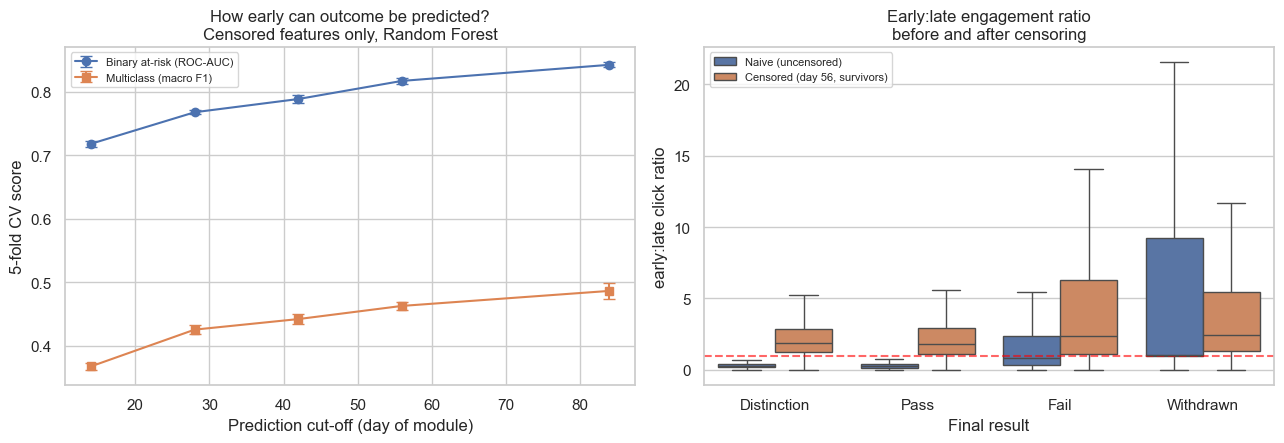

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

a = sweep[(sweep.task == 'binary_at_risk') & (sweep.model == 'RandomForest')]
b = sweep[(sweep.task == 'multiclass') & (sweep.model == 'RandomForest')]
axes[0].errorbar(a.cutoff_day, a.roc_auc_mean, yerr=a.roc_auc_sd, marker='o', capsize=4,
                 label='Binary at-risk (ROC-AUC)')
axes[0].errorbar(b.cutoff_day, b.macro_f1_mean, yerr=b.macro_f1_sd, marker='s', capsize=4,
                 label='Multiclass (macro F1)')
axes[0].set_xlabel('Prediction cut-off (day of module)')
axes[0].set_ylabel('5-fold CV score')
axes[0].set_title('How early can outcome be predicted?\nCensored features only, Random Forest')
axes[0].legend(fontsize=8)

order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
pl = pd.concat([
    orig.assign(spec='Naive (uncensored)')[['final_result', 'early_late_ratio', 'spec']],
    frames[56].assign(spec='Censored (day 56, survivors)')[
        ['final_result', 'early_late_ratio', 'spec']]])
sns.boxplot(data=pl, x='final_result', y='early_late_ratio', hue='spec', order=order,
            ax=axes[1], showfliers=False)
axes[1].axhline(1.0, color='red', linestyle='--', alpha=.6)
axes[1].set_title('Early:late engagement ratio\nbefore and after censoring')
axes[1].set_xlabel('Final result'); axes[1].set_ylabel('early:late click ratio')
axes[1].legend(fontsize=8, title=None)

plt.tight_layout()
plt.savefig(Path(FIG_DIR) / '13_censored_reanalysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Censored specification

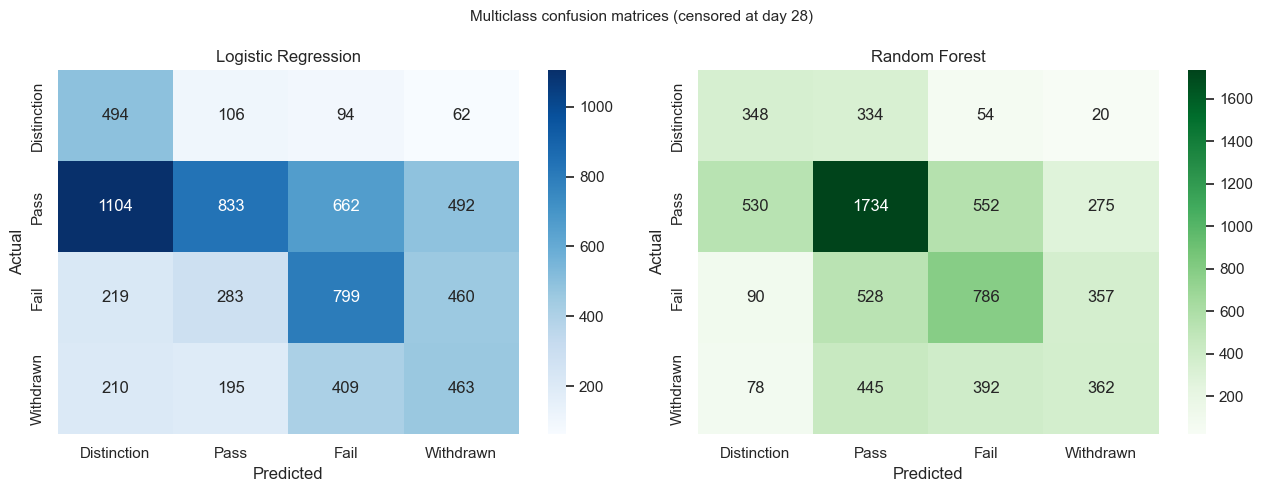

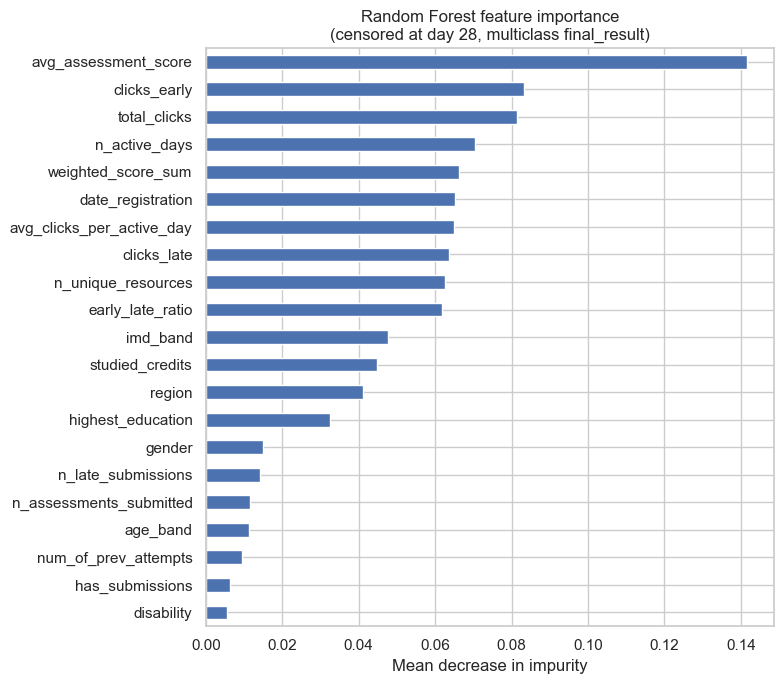

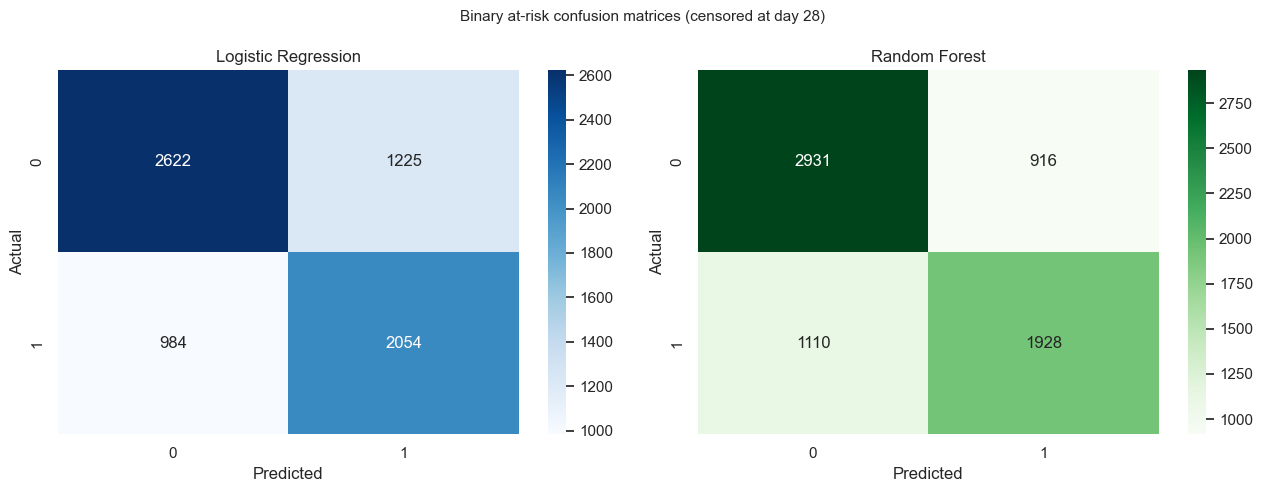

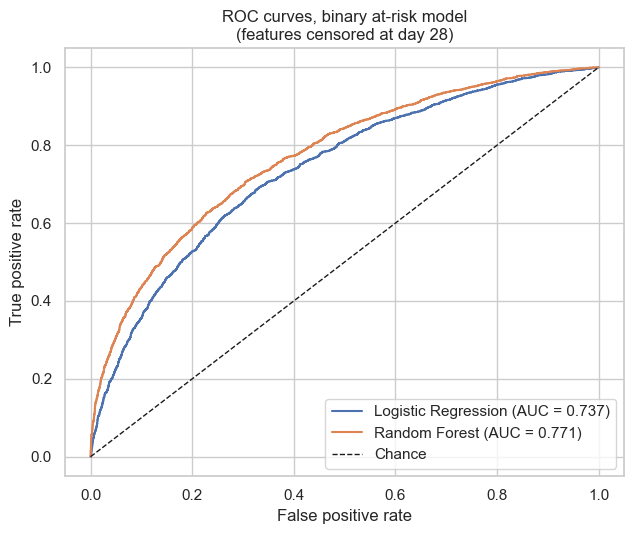

Figures regenerated. All result tables are in results/.


In [15]:
# Figures 9-12 in the original paper were produced from the uncensored models and
# contradict the revised results, so they are regenerated here on the day-28 specification.
Xf = d28[SETS['C_plus_censored_assessment'][0] + SETS['C_plus_censored_assessment'][1]].copy()
Xf[DEMC] = OrdinalEncoder().fit_transform(Xf[DEMC].astype(str))
Xf = Xf.astype(float)

def fit_pair(y):
    Xtr, Xte, ytr, yte = train_test_split(Xf, y, test_size=.25,
                                          random_state=RANDOM_STATE, stratify=y)
    lr = Pipeline([('s', StandardScaler()),
                   ('m', LogisticRegression(max_iter=2000,
                                            class_weight='balanced'))]).fit(Xtr, ytr)
    rf = RandomForestClassifier(n_estimators=279, max_depth=14, min_samples_leaf=6,
                                max_features='log2', class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr)
    return Xte, yte, lr, rf

def cm_pair(Xte, yte, lr, rf, labels, fname, title):
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for a, (m, nm, cmap) in zip(ax, [(lr, 'Logistic Regression', 'Blues'),
                                     (rf, 'Random Forest', 'Greens')]):
        C = confusion_matrix(yte, m.predict(Xte), labels=labels)
        sns.heatmap(C, annot=True, fmt='d', cmap=cmap, ax=a,
                    xticklabels=labels, yticklabels=labels)
        a.set_title(nm); a.set_xlabel('Predicted'); a.set_ylabel('Actual')
    plt.suptitle(title, fontsize=11); plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()

L = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
Xte, yte, lr, rf = fit_pair(d28['final_result'])
cm_pair(Xte, yte, lr, rf, L, Path(FIG_DIR) / '09_confusion_multiclass_censored.png',
        'Multiclass confusion matrices (censored at day 28)')

impf = pd.Series(rf.feature_importances_, index=Xf.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
impf.plot(kind='barh', ax=ax, color=sns.color_palette('deep')[0])
ax.set_title('Random Forest feature importance\n(censored at day 28, multiclass final_result)')
ax.set_xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.savefig(Path(FIG_DIR) / '12_feature_importance_censored.png', dpi=150, bbox_inches='tight')
plt.show()

Xte, yte, lr, rf = fit_pair(d28['at_risk'])
cm_pair(Xte, yte, lr, rf, [0, 1], Path(FIG_DIR) / '10_confusion_binary_censored.png',
        'Binary at-risk confusion matrices (censored at day 28)')

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for m, nm in [(lr, 'Logistic Regression'), (rf, 'Random Forest')]:
    p = m.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(yte, p)
    ax.plot(fpr, tpr, label=f'{nm} (AUC = {roc_auc_score(yte, p):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curves, binary at-risk model\n(features censored at day 28)')
ax.legend()
plt.tight_layout()
plt.savefig(Path(FIG_DIR) / '11_roc_binary_censored.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figures regenerated. All result tables are in results/.')

## 16. Mapping outputs to the manuscript

| Output | Where it goes |
|---|---|
| `table2_demographics_full.csv` | Table 2 |
| `table4_dispersion.csv`, `table4_kruskal_wallis.csv`, `table4_pairwise_mannwhitney_holm.csv` | Table 4 and its note |
| `table4b_early_late_ratio_censored.csv` | Table 4b |
| `table4c_score_submitters_only.csv` | Assessment-score figures in Results |
| `table5_censored_cv_results.csv` | Table 5 (ablation) |
| `table5b_leakage_quantified.csv` | Table 6 (leakage) |
| `table6_tuned_randomforest.csv` | Tuning sentence in Results |
| `table7_cutoff_sweep.csv` | Table 7 |
| `table8_feature_importance_censored.csv` | Figure 12 discussion |
| `figures/09–13*.png` | Figures 9, 10, 11, 12, 13 |